# 다중공선성 분석

1. 상관관계 히트맵
2. VIF (Variance Inflation Factor)
3. 제거 대상 변수 확정

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE = Path('..').resolve()
df_raw = pd.read_csv(
    BASE / 'data/02_interim/260506_feature_engineering/promotion_0_membership_v3.csv',
    encoding='utf-8-sig'
)
print(f'원본 shape: {df_raw.shape}')

원본 shape: (7323, 67)


In [9]:
import numpy as np

DROP_COLS = [
    # 식별자/날짜/문자열
    'USER_KEY','product_code','payment_device','device_group',
    'gender','reg_date','end_date','age_group','price_tier',
    # 타겟
    'is_repurchase',
    # 원본 → 파생변수로 대체
    'reg_hour', 'max_screen',
    # 상수 (분산=0)
    'is_promotion','plan_promotion','korean_ratio',
    # 더미 함정 / 완전 중복 (VIF=inf)
    'is_basic','is_family_plan',
    # 시청 변수 중복 (total_watch_time ≈ dur_w1+dur_w2+dur_w3)
    'total_watch_time',
    # 제거 결정된 파생변수
    'price_per_screen','is_new_product','is_apple_ecosystem',
    'weekday_watch_ratio','is_long_sub','hour_x_weekend','verified_x_age',
]
DROP_COLS = [c for c in DROP_COLS if c in df_raw.columns]

df = df_raw.drop(columns=DROP_COLS)
df_num = df.select_dtypes(include=[np.number]).fillna(0)

# 분산=0 컬럼 제거
zero_var = df_num.columns[df_num.var() == 0].tolist()
if zero_var:
    print(f'분산=0 추가 제거: {zero_var}')
    df_num = df_num.drop(columns=zero_var)

print(f'분석 대상 변수: {df_num.shape[1]}개')
print(list(df_num.columns))


분산=0 추가 제거: ['has_watch_history']
분석 대상 변수: 47개
['price', 'billing_method', 'is_churn_prevented', 'is_user_verified', 'age', 'duration_days', 'reg_hour_group', 'is_usd', 'price_per_day', 'gender_enc', 'age_x_screen', 'is_senior_unverified', 'is_young_unverified', 'is_standard', 'is_premium', 'genre_diversity', 'avg_showtime', 'genre_액션_ratio', 'genre_드라마_ratio', 'genre_로맨스_ratio', 'genre_스릴러_ratio', 'genre_애니메이션_ratio', 'genre_공포_ratio', 'genre_코미디_ratio', 'genre_SF_ratio', 'total_sessions', 'unique_movies', 'active_days', 'avg_session_time', 'activity_rate', 'watch_per_day', 'avg_rewatch_ratio', 'signup_to_first_watch', 'recency', 'completion_rate', 'weekend_watch_ratio', 'max_gap_between_watch_days', 'dur_w1', 'dur_w2', 'dur_w3', 'retention_w2', 'retention_w3', 'retention_w2_ratio', 'retention_w3_ratio', 'is_new_movie', 'binge_day_count', 'stream_watch_interaction']


## 1. 상관관계 히트맵

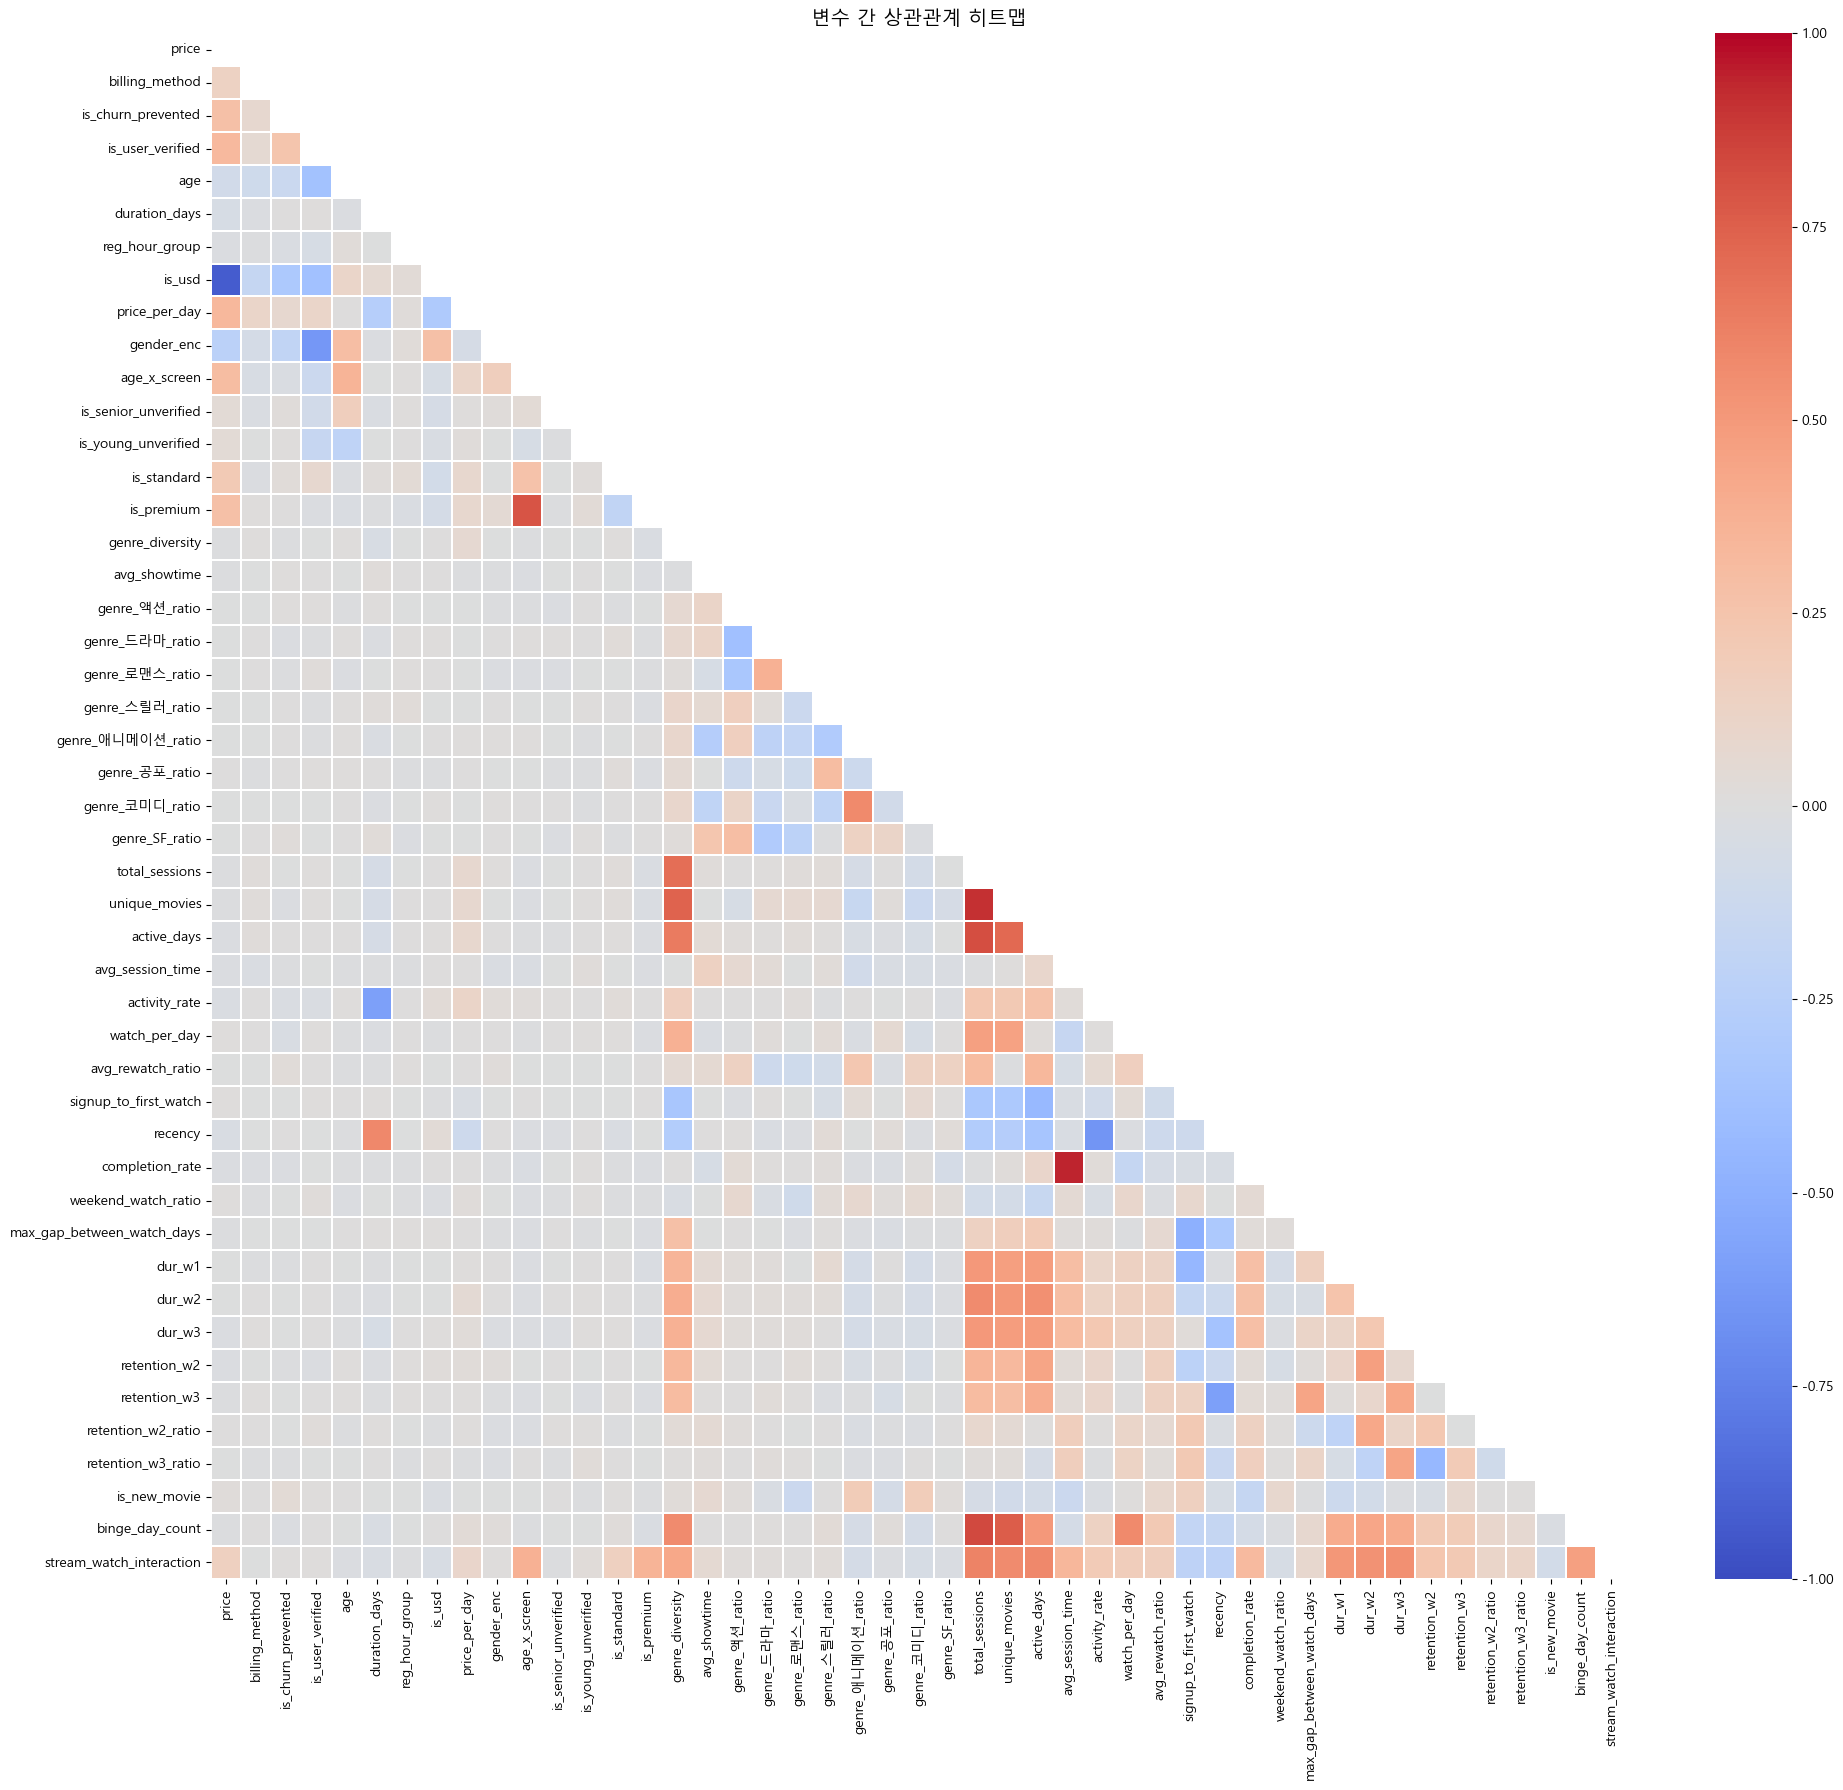

In [10]:
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(20, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax
)
ax.set_title('변수 간 상관관계 히트맵', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# 절댓값 상관계수 0.7 이상 쌍 출력
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) >= 0.7:
            high_corr.append({
                '변수1': corr.columns[i],
                '변수2': corr.columns[j],
                '상관계수': round(val, 3)
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('상관계수', key=abs, ascending=False)
print(f'상관계수 |r| >= 0.7 쌍: {len(high_corr_df)}개')
high_corr_df

상관계수 |r| >= 0.7 쌍: 9개


,변수1,변수2,상관계수
8,avg_session_time,completion_rate,0.942
0,price,is_usd,-0.923
3,total_sessions,unique_movies,0.911
5,total_sessions,binge_day_count,0.831
4,total_sessions,active_days,0.816
1,age_x_screen,is_premium,0.789
7,unique_movies,binge_day_count,0.765
2,genre_diversity,unique_movies,0.742
6,unique_movies,active_days,0.719


## 2. VIF (분산팽창계수)

- VIF < 5: 문제 없음
- VIF 5~10: 주의
- VIF > 10: 심각한 다중공선성

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 상수항 추가
X = df_num.copy()
X.insert(0, 'const', 1)

vif_data = pd.DataFrame()
vif_data['변수'] = X.columns[1:]  # const 제외
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i+1)
    for i in range(len(X.columns)-1)
]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
vif_data['위험도'] = vif_data['VIF'].apply(
    lambda v: '🔴 심각' if v > 10 else ('🟡 주의' if v > 5 else '🟢 양호')
)

print('=== VIF 결과 ===')  
print(vif_data.to_string())

=== VIF 결과 ===
                            변수        VIF   위험도
0               total_sessions  28.760917  🔴 심각
1                 age_x_screen  19.152476  🔴 심각
2                   is_premium  18.236480  🔴 심각
3                unique_movies  15.619593  🔴 심각
4                        price  15.582217  🔴 심각
5                       is_usd  13.919373  🔴 심각
6             avg_session_time  13.905228  🔴 심각
7              completion_rate  12.961936  🔴 심각
8                  active_days  12.488893  🔴 심각
9                      recency   6.666606  🟡 주의
10                 is_standard   5.574585  🟡 주의
11    stream_watch_interaction   4.955025  🟢 양호
12             binge_day_count   4.781413  🟢 양호
13       signup_to_first_watch   4.622099  🟢 양호
14                         age   4.239870  🟢 양호
15             genre_diversity   3.717255  🟢 양호
16  max_gap_between_watch_days   3.606912  🟢 양호
17                      dur_w3   3.578687  🟢 양호
18                retention_w3   3.404973  🟢 양호
19                      d

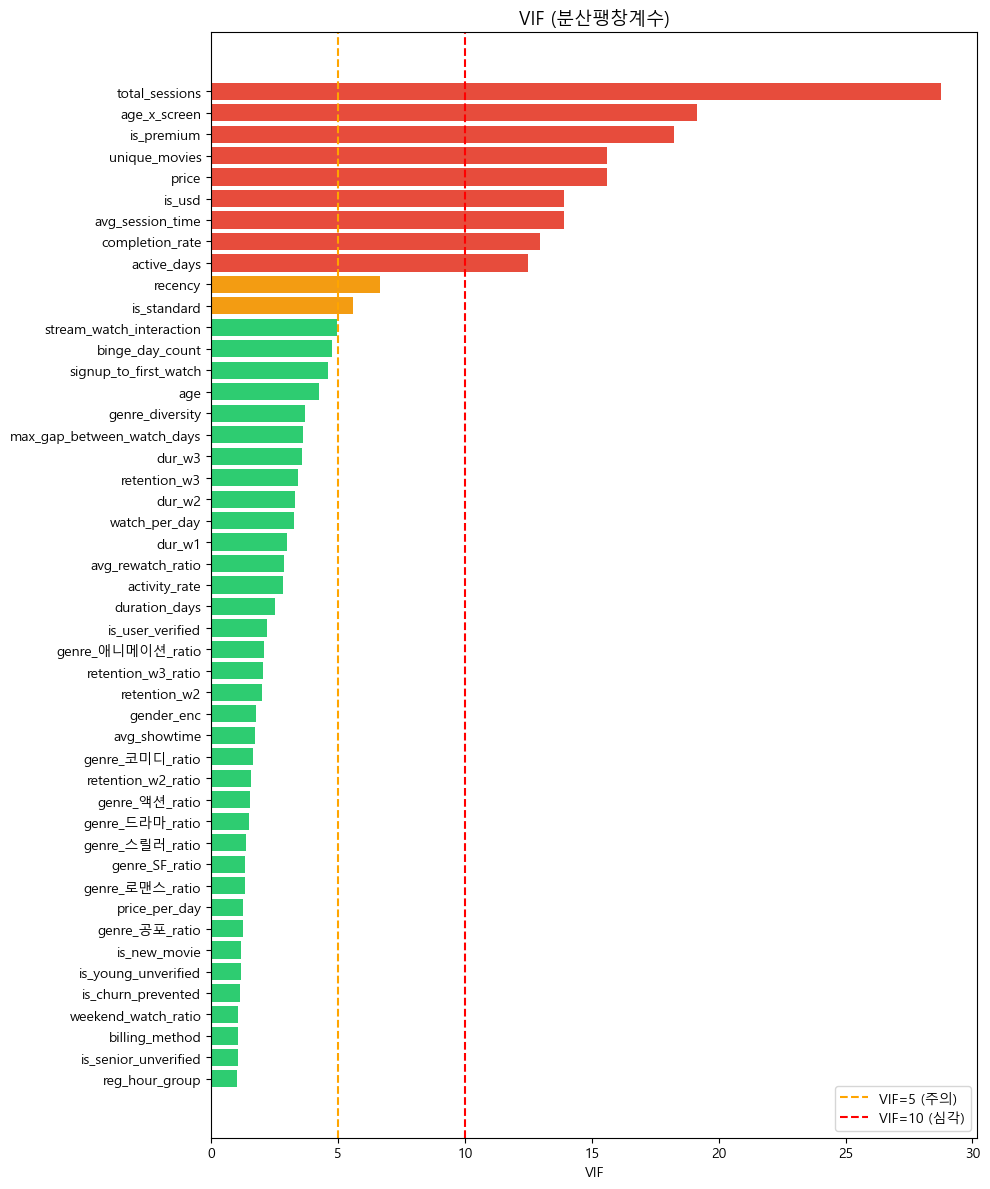

In [13]:
# VIF 시각화
fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
          for v in vif_data['VIF']]
ax.barh(vif_data['변수'][::-1], vif_data['VIF'][::-1], color=colors[::-1])
ax.axvline(x=5,  color='orange', linestyle='--', label='VIF=5 (주의)')
ax.axvline(x=10, color='red',    linestyle='--', label='VIF=10 (심각)')
ax.set_title('VIF (분산팽창계수)', fontsize=13)
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()

## 3. 제거 검토 대상 정리

In [14]:
print('=== VIF > 10 (심각) ===')  
print(vif_data[vif_data['VIF'] > 10][['변수','VIF']].to_string())

print()
print('=== VIF 5~10 (주의) ===')
print(vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)][['변수','VIF']].to_string())

print()
print('참고: XGBoost는 다중공선성에 강하므로 VIF > 10이어도 SHAP 분석 후 최종 결정')

=== VIF > 10 (심각) ===
                 변수        VIF
0    total_sessions  28.760917
1      age_x_screen  19.152476
2        is_premium  18.236480
3     unique_movies  15.619593
4             price  15.582217
5            is_usd  13.919373
6  avg_session_time  13.905228
7   completion_rate  12.961936
8       active_days  12.488893

=== VIF 5~10 (주의) ===
             변수       VIF
9       recency  6.666606
10  is_standard  5.574585

참고: XGBoost는 다중공선성에 강하므로 VIF > 10이어도 SHAP 분석 후 최종 결정
